## Soft Voting and cross validation##

In [1]:
import sys
import os
import gc
import pandas as pd
import joblib
import matplotlib.pyplot as plt


#sistemare il warning di LightGBM fa creare warning a tutti gli altri modelli addestrati senza
#feature name, quindi meglio ingorarli
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Add the package root to sys.path so we can import stellar_classification
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))

import stellar_classification as sc

# Enable garbage collection
gc.enable()
gc.collect()

/home/nikko/miniconda3/envs/comp_phys/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


20

In [2]:
# Load dataset
data_path = '../stellar_classification/stellar_classification/data/star_classification.csv'
star = pd.read_csv(data_path)

print("First few rows:")
display(star.head())

print("\nData Info:")
star.info()

print("\nNull Values:")
print(star.isnull().sum())

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)

# -------- Color indexes ----------

star["u_g"] = star["u"] - star["g"]
star["g_r"] = star["g"] - star["r"]
star["r_i"] = star["r"] - star["i"]
star["i_z"] = star["i"] - star["z"]

star.info()


First few rows:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7)

In [3]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler, feature_names = sc.prepare_splits(
    star, 
    target_col='class', 
    test_size=0.2, 
    val_ratio=0.25, 
    random_state=42, 
    apply_outlier_removal=True
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)


Outliers removed: 8,715 rows  (91,285 remain)
X_train shape: (97032, 13)
X_val shape: (18257, 13)
X_test shape: (18257, 13)

Class Distribution:
class
GALAXY    59.445
STAR      21.594
QSO       18.961
Name: proportion, dtype: float64


In [6]:
models = sc.train_traditional(X_train, y_train, X_val, y_val)

Linear SVC trained.
  [Training] Acc=73.09%  P=0.73  R=0.73  F1=0.73
  [Validation] Acc=71.57%  P=0.67  R=0.72  F1=0.69
Decision Tree trained.
  [Training] Acc=100.00%  P=1.00  R=1.00  F1=1.00
  [Validation] Acc=84.78%  P=0.80  R=0.82  F1=0.81
Random Forest trained.
  [Training] Acc=100.00%  P=1.00  R=1.00  F1=1.00
  [Validation] Acc=90.47%  P=0.88  R=0.88  F1=0.88
LightGBM trained.
  [Training] Acc=91.71%  P=0.92  R=0.92  F1=0.92
  [Validation] Acc=90.32%  P=0.87  R=0.88  F1=0.88
XGBoost trained.
  [Training] Acc=98.35%  P=0.98  R=0.98  F1=0.98
  [Validation] Acc=90.71%  P=0.88  R=0.88  F1=0.88


In [7]:
soft_voting_clf = sc.train_voting(X_train, y_train, X_val, y_val, models=models, voting='soft')


Voting Classifier trained.
  [Training] Acc=99.69%  P=1.00  R=1.00  F1=1.00
  [Validation] Acc=90.33%  P=0.87  R=0.88  F1=0.88


In [6]:
from sklearn.model_selection import cross_validate
from sklearn.ensemble import VotingClassifier
import numpy as np

X_search = np.concatenate([X_train, X_val], axis=0)
y_search = np.concatenate([y_train, y_val], axis=0)
print(f"X_search shape is: {X_search.shape} \ny_search shape is: {y_search.shape}")

weight_combinations = [
    [1, 1, 1, 1],
    [1, 2, 2, 2],
    [1, 1, 2, 2],
    [1, 2, 3, 3],
    [1, 1, 3, 3],
    [2, 3, 3, 3],
]

results = []

estimators = [
    ('dt',   models['Decision Tree']),
    ('rf',   models['Random Forest']),
    ('lgbm', models['LightGBM']),
    ('xgb',  models['XGBoost']),
]

for weights in weight_combinations:
    clf = VotingClassifier(estimators=estimators, voting='soft', weights=weights)
    
    cv_results = cross_validate(
        clf, X_search, y_search,
        cv=3,
        scoring='f1_weighted',
        n_jobs=1,
        return_train_score=True
    )
    
    train_f1 = cv_results['train_score'].mean()
    val_f1 = cv_results['test_score'].mean()
    gap = abs(train_f1 - val_f1)
    
    results.append({
        'weights': weights,
        'train_f1': train_f1,
        'val_f1': val_f1,
        'gap': gap
    })
    print(f"weights={weights} -> train_f1={train_f1:.4f} val_f1={val_f1:.4f} gap={gap:.4f}")

results_df = pd.DataFrame(results).sort_values('gap')
display(results_df)

X_search shape is: (115289, 13) 
y_search shape is: (115289,)
weights=[1, 1, 1, 1] -> train_f1=0.9965 val_f1=0.9264 gap=0.0701
weights=[1, 2, 2, 2] -> train_f1=0.9898 val_f1=0.9278 gap=0.0620
weights=[1, 1, 2, 2] -> train_f1=0.9855 val_f1=0.9261 gap=0.0595
weights=[1, 2, 3, 3] -> train_f1=0.9830 val_f1=0.9265 gap=0.0565
weights=[1, 1, 3, 3] -> train_f1=0.9791 val_f1=0.9252 gap=0.0538
weights=[2, 3, 3, 3] -> train_f1=0.9925 val_f1=0.9277 gap=0.0648


,weights,train_f1,val_f1,gap
4,"[1, 1, 3, 3]",0.979077,0.925249,0.053828
3,"[1, 2, 3, 3]",0.983002,0.926463,0.056539
2,"[1, 1, 2, 2]",0.985548,0.926090,0.059458
1,"[1, 2, 2, 2]",0.989784,0.927789,0.061994
5,"[2, 3, 3, 3]",0.992472,0.927655,0.064816
0,"[1, 1, 1, 1]",0.996487,0.926436,0.070051


In [7]:
best_weights = results_df.iloc[0]['weights']
print("Best weights:", best_weights)

soft_voting_clf = VotingClassifier(
    estimators=estimators,
    voting='soft',
    weights=best_weights
)
soft_voting_clf.fit(X_train, y_train)

Best weights: [1, 1, 3, 3]


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('dt', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.","[1, 1, ...]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1



Soft Voting Classifier:
  Accuracy  : 91.00%
  Precision: 0.8824
  Recall   : 0.8867
  F1       : 0.8842
  Confusion Matrix:
[[10218   336   227]
 [  229  3077   242]
 [  250   359  3319]]
Saved: /home/nikko/Immagini/res/conf_matrix/soft_voting(best_weights).png


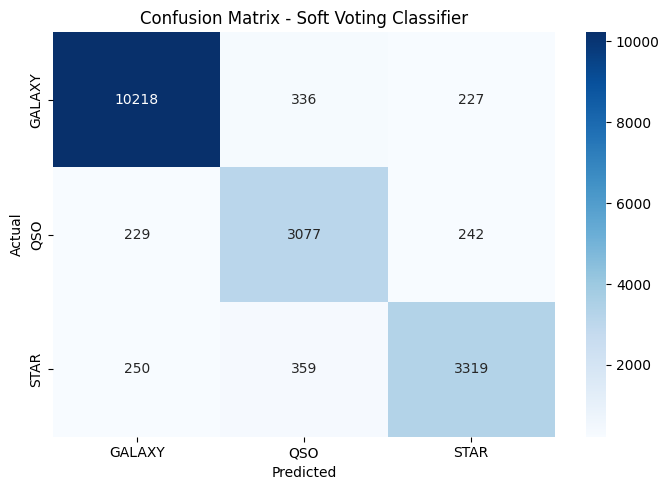

1 batch shape: 4000
2 batch shape: 4000
3 batch shape: 4000
4 batch shape: 4000
5 batch shape: 2257
[array([0.0086 , 0.0074 , 0.00375, 0.01095, 0.0046 , 0.0036 , 0.0135 ,
       0.0343 , 0.02335, 0.1068 , 0.0807 , 0.17505, 0.0486 ]), array([0.0055 , 0.00785, 0.00355, 0.00985, 0.00445, 0.00295, 0.01475,
       0.03995, 0.02365, 0.10235, 0.06185, 0.17605, 0.0595 ]), array([0.00685, 0.00915, 0.0031 , 0.0108 , 0.0035 , 0.00945, 0.0193 ,
       0.0378 , 0.02645, 0.10925, 0.06875, 0.1733 , 0.05105]), array([0.00795, 0.0109 , 0.006  , 0.0099 , 0.0041 , 0.0061 , 0.01495,
       0.0345 , 0.0257 , 0.10625, 0.0683 , 0.18215, 0.05195]), array([0.00691183, 0.01027913, 0.00505095, 0.01665928, 0.00381037,
       0.00575986, 0.00992468, 0.03367302, 0.02277359, 0.11067789,
       0.06991582, 0.16836509, 0.05414267])]
Saved: /home/nikko/Immagini/res/permutation_importances/soft_voting(best_weights).png


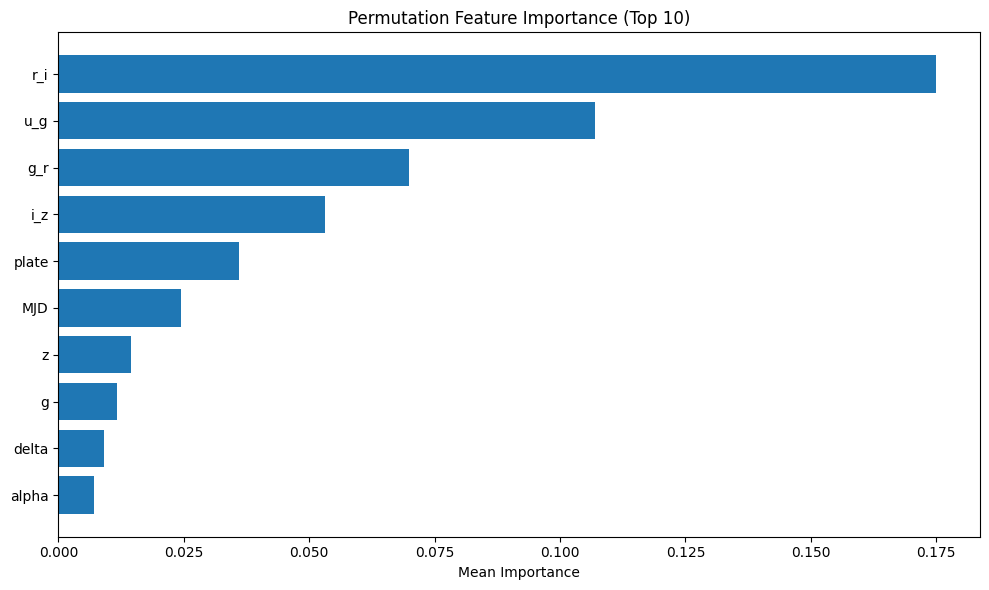

Feature Importance Scores:
r_i: 0.1750
u_g: 0.1071
g_r: 0.0699
i_z: 0.0530
plate: 0.0360
MJD: 0.0244
z: 0.0145
g: 0.0116
delta: 0.0091
alpha: 0.0072
i: 0.0056
u: 0.0043
r: 0.0041


In [8]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

y_test_pred_voting = soft_voting_clf.predict(X_test)
soft_voting_metrics = sc.evaluate_test_set(y_test, y_test_pred_voting, "Soft Voting Classifier")
sc.print_metrics(soft_voting_metrics)

class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(soft_voting_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Soft Voting Classifier', save_path='/home/nikko/Immagini/res/conf_matrix/soft_voting(best_weights).png')

imp = sc.compute_permutation_importance(soft_voting_clf, X_test, y_test, feature_names=feature_names, n_jobs=4)
sc.plot_permutation_importance(imp, top_n=10, save_path='/home/nikko/Immagini/res/permutation_importances/soft_voting(best_weights).png')

print("Feature Importance Scores:")
for feat, val in imp.items():
    print(f"{feat}: {val:.4f}")

Saved: /home/nikko/Immagini/res/ablation/Soft_Voting_ablation(best_weights).png


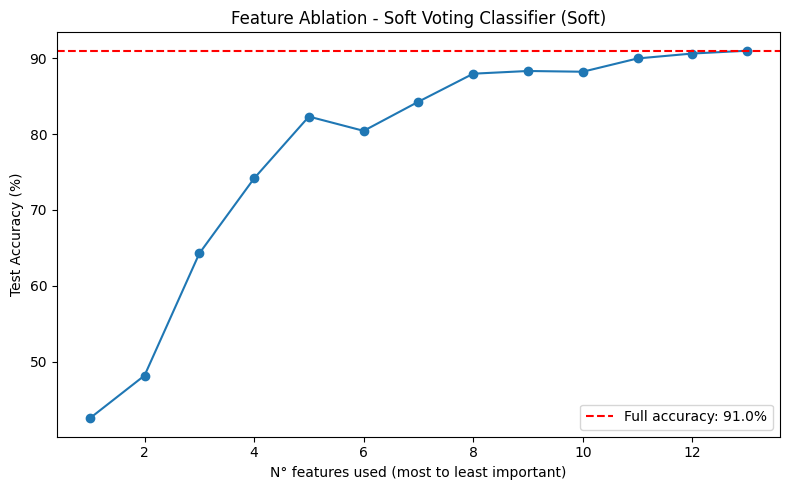

In [9]:
sc.plot_feature_ablation(
    soft_voting_clf,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    feature_names=feature_names,
    title='Feature Ablation - Soft Voting Classifier (Soft)',
    save_path='/home/nikko/Immagini/res/ablation/Soft_Voting_ablation(best_weights).png'
)

In [10]:
train_m = sc.compute_metrics(y_train, soft_voting_clf.predict(X_train), 'Training',   'Soft Voting Classifier')
val_m   = sc.compute_metrics(y_val,   soft_voting_clf.predict(X_val),   'Validation', 'Soft Voting Classifier')
for m in (train_m, val_m):
    print(
        f"  [{m['dataset']}] Acc={m['accuracy']:.2f}%  "
        f"P={m['precision']:.2f}  R={m['recall']:.2f}  F1={m['f1']:.2f}"
    )


  [Training] Acc=98.11%  P=0.98  R=0.98  F1=0.98
  [Validation] Acc=90.78%  P=0.88  R=0.88  F1=0.88


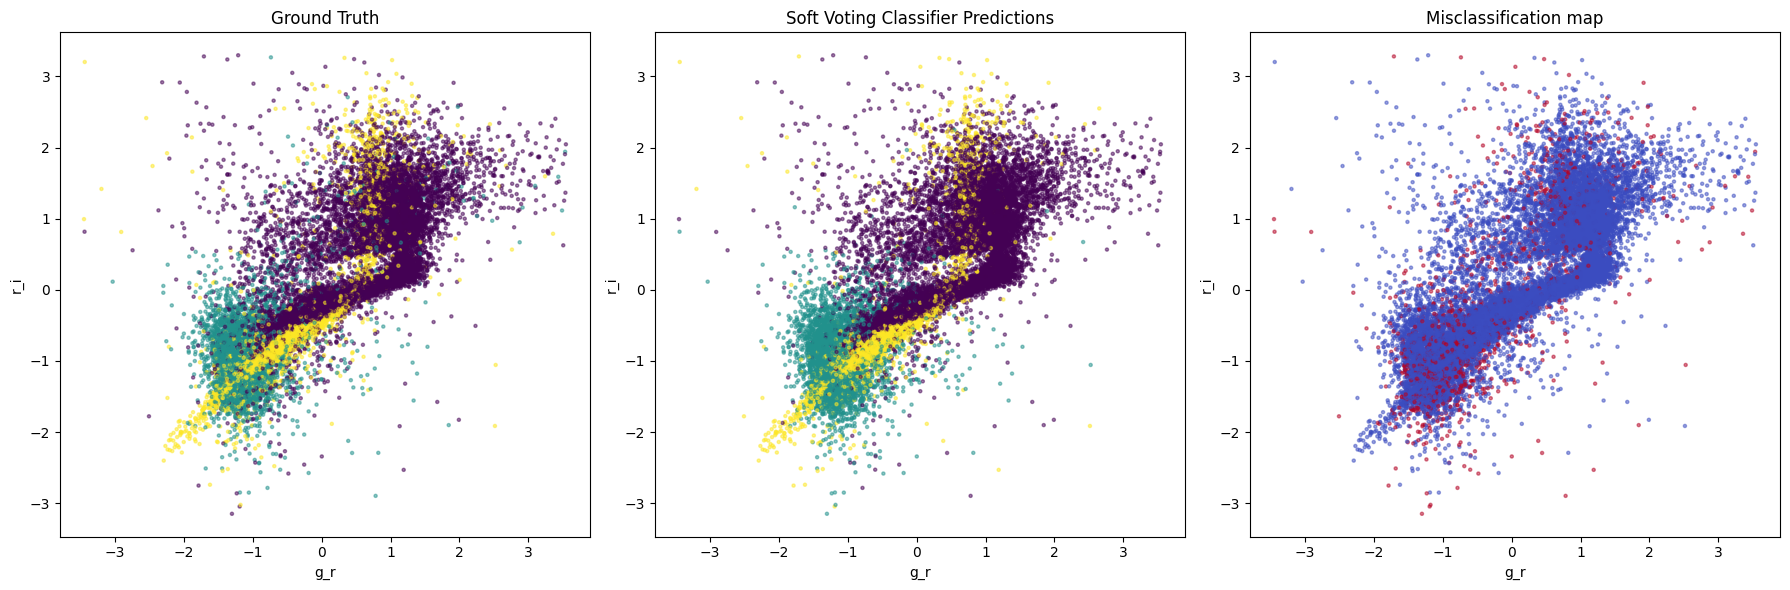

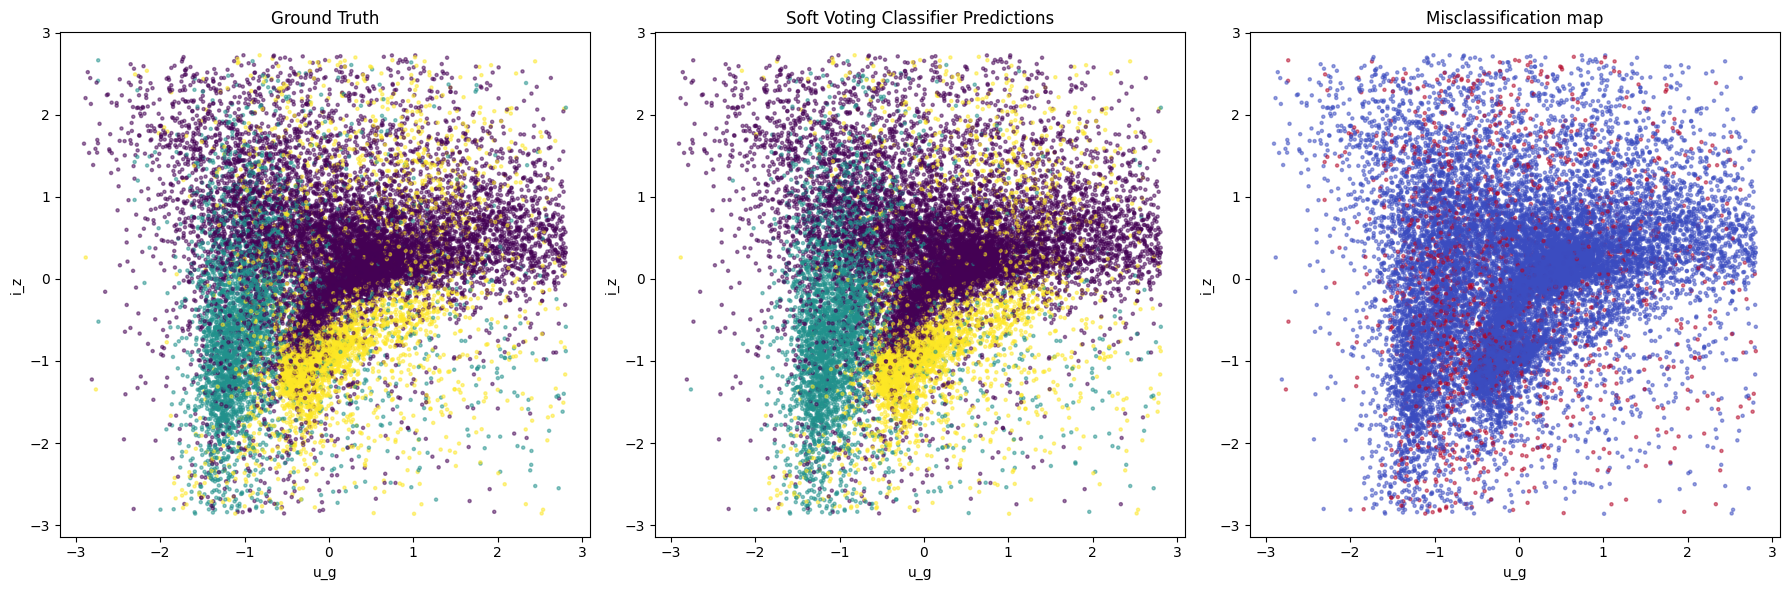

In [11]:
X_test_df = pd.DataFrame(X_test, columns=feature_names)
y_pred_voting = soft_voting_clf.predict(X_test)

# g-r vs r-i
sc.plot_prediction_and_error_map(
    X=X_test_df,
    y_true=y_test,
    y_pred=y_pred_voting,
    feature_x='g_r',
    feature_y='r_i',
    title_prefix='Soft Voting Classifier',
    save_path='/home/nikko/Immagini/res/ablation/Soft_Voting_errors(1).png'
)


# u-g vs i-z
sc.plot_prediction_and_error_map(
    X=X_test_df,
    y_true=y_test,
    y_pred=y_pred_voting,
    feature_x='u_g',
    feature_y='i_z',
    title_prefix='Soft Voting Classifier',
    save_path='/home/nikko/Immagini/res/ablation/Soft_Voting_errors(2).png'
)


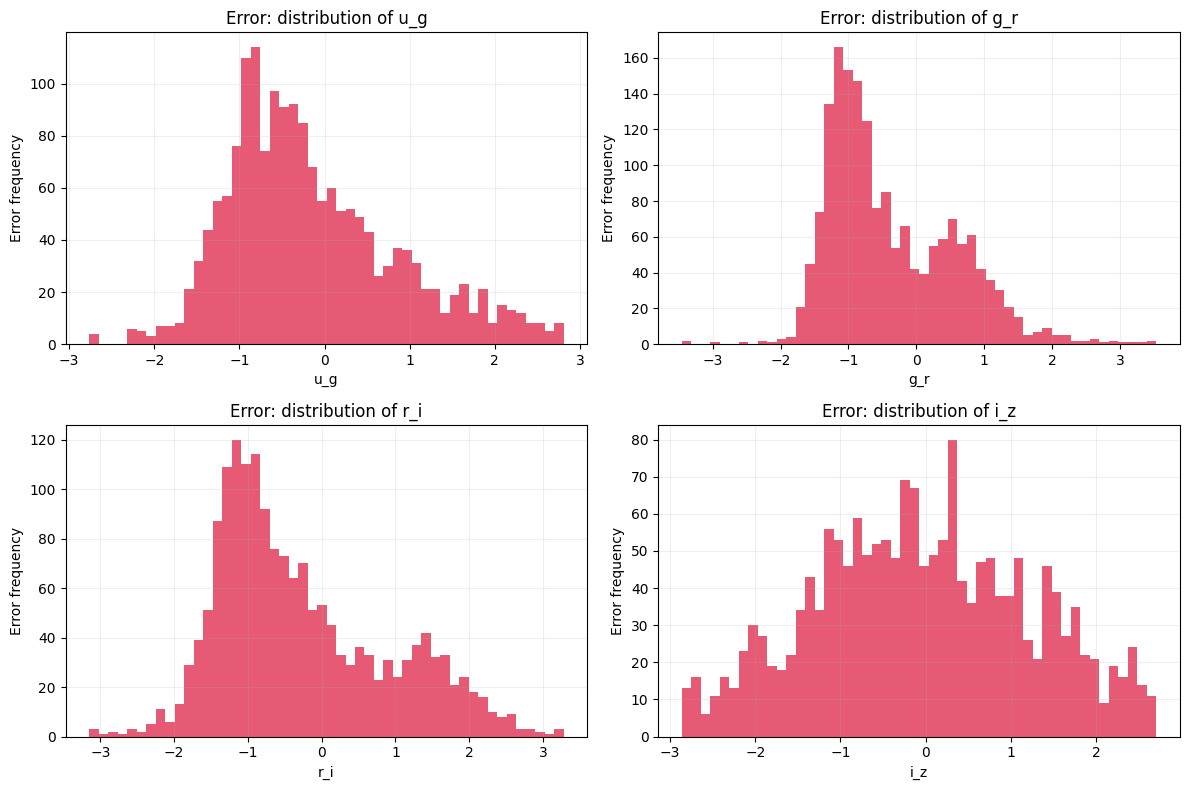

In [9]:
X_test_df = pd.DataFrame(X_test, columns=feature_names)
y_pred_voting = soft_voting_clf.predict(X_test)

sc.plot_misclassified_feature_distributions(
    X_test_df,
    y_test,
    y_pred_voting,
    features=["u_g", "g_r", "r_i", "i_z"],
    save_path='/home/nikko/Immagini/res/errorssoft_Voting_misc.png'
)